In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

data = r'C:\Users\Noman khan\Downloads\archive (2)\Housing.csv'
df = pd.read_csv(data)

print(df.head())
print(df.info())
print(df.columns)
print(df.dtypes)
#print(df.describe())


      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 colu

In [5]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea']
for cols in binary_cols:
    if df[cols].dtype == "object":

        df[cols] = df[cols].str.lower().str.strip().map({"yes":1, "no":0})

df_final = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True, dtype=int)
print(df_final.select_dtypes(include=object).columns)
print(df_final.isnull().sum())
X = df_final.drop('price', axis=1)
y = df_final['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

Index([], dtype='object')
price                              0
area                               0
bedrooms                           0
bathrooms                          0
stories                            0
mainroad                           0
guestroom                          0
basement                           0
hotwaterheating                    0
airconditioning                    0
parking                            0
prefarea                           0
furnishingstatus_semi-furnished    0
furnishingstatus_unfurnished       0
dtype: int64


In [6]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred  = model.predict(X_test)


In [11]:
rmse = np.sqrt(np.mean((y_pred - y_test)**2))
print("RMSE: ", rmse)

RMSE:  1324506.9600914386


In [12]:
r2score = r2_score(y_test, y_pred)
print("R2 Score: ",r2score)

R2 Score:  0.6529242642153184


In [16]:
y_mean = np.mean(y_test)
percentage_error = (rmse/y_mean) * 100
print(f"Average Target Value:  {y_mean:,.2f}")
print(f"RMSE as % of Average: {percentage_error:.2f}")




Average Target Value:  5,007,536.70
RMSE as % of Average: 26.45


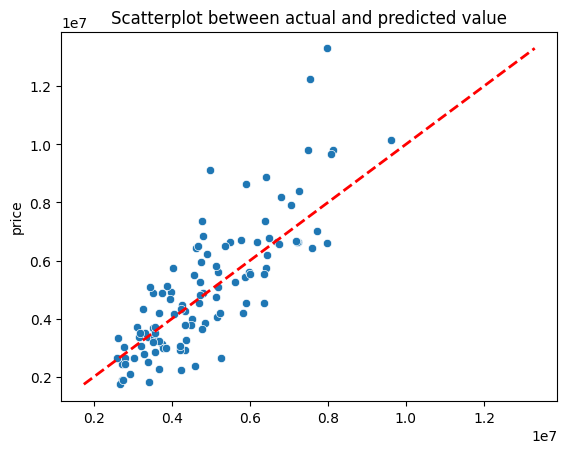

In [24]:
sns.scatterplot(x=y_pred, y=y_test)
plt.title("Scatterplot between actual and predicted value")
max_val = max(np.max(y_test), np.max(y_pred))
min_val = min(np.min(y_test), np.min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", lw=2)
plt.show()

## R2 Score for Non-Technical People
Our model successfully explains 65.3% of why prices vary. It understands the main factors driving most price changes. The remaining 35% comes from missing information or unpredictable real-world details. Think of it as a solid, reliable guide that captures the big picture but misses some specific nuanc 